In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("..\\data\\raw\\TOA19.20260615112451.csv")

df_raw = pd.read_csv(csv_path)

df = df_raw.rename(columns={
    "City Services": "city",
    "Time of Day": "time_segment",
    "VALUE": "daily_flow_percent"
})[["Year", "city", "time_segment", "daily_flow_percent"]].copy()

In [2]:
start_year = 2013
end_year = 2023

df_period = df[
    (df["Year"].between(start_year, end_year)) &
    (df["time_segment"] != "All times")
].copy()

df_period

,Year,city,time_segment,daily_flow_percent
60,2013,Cork,00:00 - 06:59,1.0
61,2013,Cork,07:00 - 07:59,0.4
62,2013,Cork,08:00 - 08:59,5.1
63,2013,Cork,09:00 - 09:59,7.4
64,2013,Cork,10:00 - 12:59,18.6
...,...,...,...,...
714,2023,Dublin,16:00 - 16:59,8.2
715,2023,Dublin,17:00 - 17:59,8.8
716,2023,Dublin,18:00 - 18:59,7.1
717,2023,Dublin,19:00 - 21:59,12.2


In [3]:
def parse_time_segment(segment: str) -> pd.Series:
    start, end = [x.strip() for x in segment.split("-")]
    
    start_hour = int(start.split(":")[0])
    end_hour = int(end.split(":")[0])
    
    duration_hours = end_hour - start_hour + 1
    
    return pd.Series({
        "start_hour": start_hour,
        "end_hour": end_hour,
        "duration_hours": duration_hours
    })

time_info = df_period["time_segment"].apply(parse_time_segment)

df_segments = pd.concat([df_period, time_info], axis=1)

df_segment_avg = (
    df_segments
    .groupby(["city", "time_segment", "start_hour", "end_hour", "duration_hours"], as_index=False)
    .agg(
        avg_segment_daily_flow_percent=("daily_flow_percent", "mean"),
        years_available=("daily_flow_percent", "count")
    )
    .sort_values(["city", "start_hour"])
)

In [4]:
df_segment_avg = (
    df_segments
    .groupby(["city", "time_segment", "start_hour", "end_hour", "duration_hours"], as_index=False)
    .agg(
        avg_segment_daily_flow_percent=("daily_flow_percent", "mean"),
        years_available=("daily_flow_percent", "count")
    )
    .sort_values(["city", "start_hour"])
)

df_segments["hourly_flow_percent"] = (
    df_segments["daily_flow_percent"] / df_segments["duration_hours"]
)

In [5]:
expanded_rows = []

for _, row in df_segments.iterrows():
    for hour in range(int(row["start_hour"]), int(row["end_hour"]) + 1):
        expanded_rows.append({
            "year": int(row["Year"]),
            "city": row["city"],
            "hour": hour,
            "time_segment": row["time_segment"],
            "hourly_flow_percent": row["hourly_flow_percent"]
        })

df_hourly_by_year = pd.DataFrame(expanded_rows)

df_hourly_avg = (
    df_hourly_by_year
    .groupby(["city", "hour"], as_index=False)
    .agg(
        avg_hourly_flow_percent=("hourly_flow_percent", "mean"),
        years_available=("hourly_flow_percent", "count")
    )
    .sort_values(["city", "hour"])
)

In [6]:
df_hourly_pivot = (
    df_hourly_avg
    .pivot(index="hour", columns="city", values="avg_hourly_flow_percent")
    .reset_index()
)

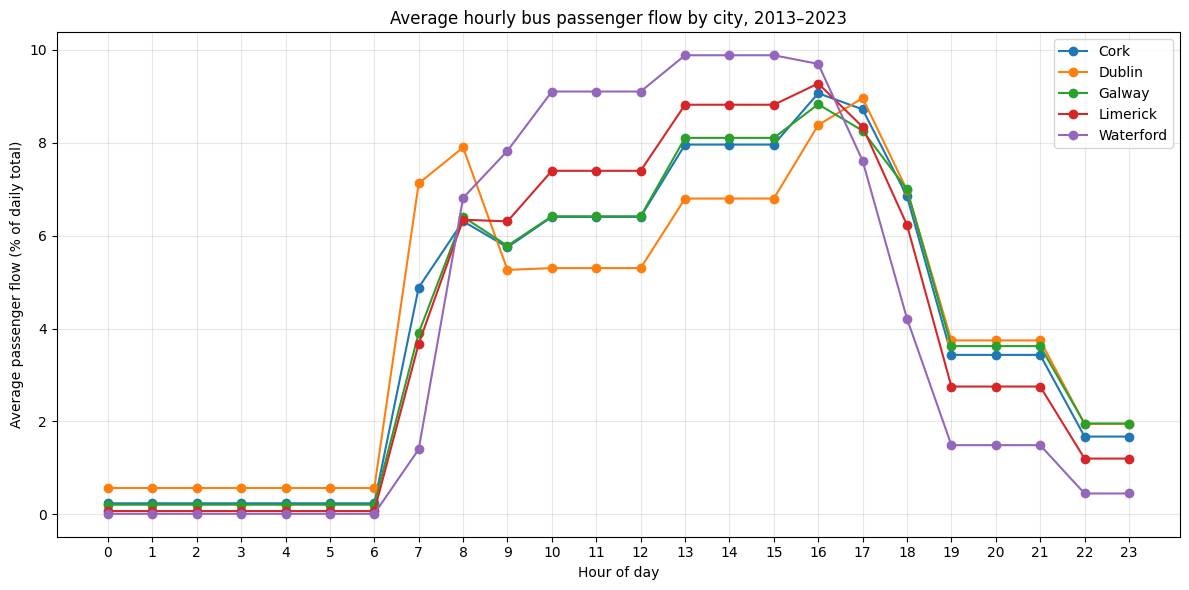

In [7]:
plt.figure(figsize=(12, 6))

for city in df_hourly_pivot.columns.drop("hour"):
    plt.plot(df_hourly_pivot["hour"], df_hourly_pivot[city], marker="o", label=city)

plt.title("Average hourly bus passenger flow by city, 2013–2023")
plt.xlabel("Hour of day")
plt.ylabel("Average passenger flow (% of daily total)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
from pathlib import Path

processed_dir = Path("../data/processed")


df_hourly_avg.to_csv(
    processed_dir / "bus_hourly_average_2013_2023_long.csv",
    index=False
)

df_hourly_pivot.to_csv(
    processed_dir / "bus_hourly_average_2013_2023_pivot.csv",
    index=False
)